<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.2 Transformação de tensões. Tensões principais. Direções principais.

## Problema 3 <a name="PI23"></a>

Considere o tensor de tensões (MPa):

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
\sigma_{11} & \tau_{21} & \tau_{31} \\
\tau_{12} & \sigma_{22} & \tau_{32} \\
\tau_{13} & \tau_{23} & \sigma_{33}
\end{bmatrix} =
\begin{bmatrix}
3 & -1 & 0 \\ -1 & 3 & 0 \\ 0 & 0 & 1
\end{bmatrix}
\end{equation*}

representado no sistema de coordenadas $S_0(O,\vec{e}_1,\vec{e}_2,\vec{e}_3)$.

[a)](#A) Represente o tensor das tensões num cubo elementar.

[b)](#B) Determine o vector tensão associado a uma superfície cujo versor normal é $\vec{n} = 1/2 \,\vec{e}_1 + 1/2 \,\vec{e}_2 - 1/\sqrt{2}\, \vec{e}_3$.

[c)](#C) Indique as componentes normal e tangencial do vector tensão.

[d)](#D) Calcule a primeira direção principal: $\sigma_\mathrm{I}~\rightarrow~\vec{n}_\mathrm{I}$.

[e)](#E) Verifique se a matriz:

\begin{equation*}
[A] =
\begin{bmatrix}
1/\sqrt{2} & -1/\sqrt{2} & 0 \\
1/\sqrt{2} & 1/\sqrt{2} & 0 \\ 0 & 0 & 1
\end{bmatrix}
\end{equation*}

pode ser uma matriz de transformação de coordenadas.



## Resolução

#### a) Represente o tensor das tensões num cubo elementar.<a name="A"></a>
([enunciatum](#PI23))

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P003_i1.jpg" width="350" height="220">


#### b) Determine o vector tensão associado a uma superfície cujo versor normal é $\vec{n} = 1/2 \,\vec{e}_1 + 1/2 \,\vec{e}_2 - 1/\sqrt{2}\, \vec{e}_3$.<a name="B"></a>
([enunciatum](#PI23))

O vetor de tensão é dado de acordo com a fórmula de Cauchy (notação indicial):

\begin{equation*}
\vec{t}{(\vec{n})} = t_1 \vec{e}_1 + t_2 \vec{e}_2 + t_3 \vec{e}_3 = t_i
\vec{e}_i =
\sigma_{ji}n_j \vec{e}_i
\end{equation*}

em que as componentes cartesianas de $\vec{t}{(\vec{n})}$ são portanto obtidas pela relação:

\begin{equation*}
t_i = \sigma_{ji}n_j
\end{equation*}

ou na forma matricial,

\begin{equation*}
\begin{bmatrix}
t_1 \\ t_2 \\ t_3
\end{bmatrix} =
\begin{bmatrix}
\sigma_{11} & \sigma_{21} & \sigma_{31} \\
\sigma_{12} & \sigma_{22} & \sigma_{32} \\
\sigma_{13} & \sigma_{23} & \sigma_{23}
\end{bmatrix}
\begin{bmatrix}
n_1 \\ n_2 \\ n_3
\end{bmatrix}
\end{equation*}



In [1]:
import numpy as np

def versor(n1,n2,n3): return np.array([n1,n2,n3])

def tensortensoes(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]])

vecn = versor(1/2,1/2,-1/np.sqrt(2))
vecnnorma = np.sqrt(np.dot(vecn,vecn))
print('\n n = ',vecn)
print('\n ||n|| = ','{:.2f}'.format(vecnnorma))

tt0 = tensortensoes(3,-1,0,3,0,1)
print('\n [sigma] = \n',tt0)

print('\n Pela formula da tensão de Cauchy:')
vetort = np.dot(tt0,vecn)
print('\n t(n) = [sigma]n = \n',vetort)



 n =  [ 0.5         0.5        -0.70710678]

 ||n|| =  1.00

 [sigma] = 
 [[ 3 -1  0]
 [-1  3  0]
 [ 0  0  1]]

 Pela formula da tensão de Cauchy:

 t(n) = [sigma]n = 
 [ 1.          1.         -0.70710678]


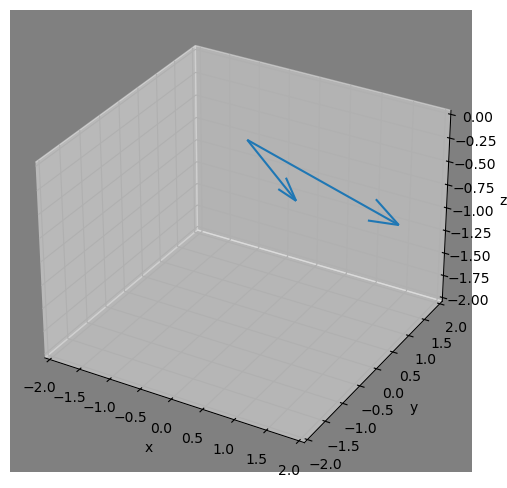

In [2]:
# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

setas = np.array( [ [0,0,0,vecn[0],vecn[1],vecn[2]], [0,0,0,vetort[0],
                                                           vetort[1],vetort[2]] ])
fig = plt.figure(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
ax = fig.add_subplot(111, projection='3d')
for i in setas:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])
ax.set_zlim([-2,0])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

#### c) Indique as componentes normal e tangencial do vector tensão.<a name="C"></a>
([enunciatum](#PI23))

A componente normal do vetor das tensões é dada por:

\begin{equation*}
\sigma_n = \underbrace{\vec{t}^{(\vec{n})}\cdot \vec{n}}_{\textrm{vetorial}} =
\underbrace{\underline{t}^{T} \underline{n}}_{\textrm{matricial}} =
\underbrace{t_i \cdot n_i}_{\textrm{indicial}} = n_i \cdot \sigma_{ji} \cdot n_j
\end{equation*}

A componente de corte do das tensões vem:

\begin{equation*}
\tau = (||\vec{t}||^2 - \sigma_n^2)^{1/2} = (\vec{t}\cdot\vec{t} - \sigma_n^2)^{1/2} = (t_1^2+ t_2^2 + t_3^2 - \sigma_n^2)^{1/2}
\end{equation*}

In [3]:
tnormal = np.dot(vetort,vecn)
print('\n sigma_n = t(n)n = ',tnormal,' MPa')

tcorte = np.sqrt(np.dot(vetort,vetort) -tnormal**2)
print('\n tau = (t(n).t(n) - sigma_n)^1/2 =',tcorte,' MPa')



 sigma_n = t(n)n =  1.5  MPa

 tau = (t(n).t(n) - sigma_n)^1/2 = 0.5  MPa


#### d)  Calcule a primeira direção principal: $\sigma_\mathrm{I}~\rightarrow~\vec{n}_\mathrm{I}$.<a name="D"></a>
([enunciatum](#PI23))

O versor $n_j$ define uma direção principal de tensão quando a orientação da faceta no ponto verificar a seguinte igualdade:

\begin{equation*}
t_i^{(n)} = \sigma_{ji}n_j = \sigma_\alpha \cdot n_j ~\textrm{($\alpha$ = I,II ou III)}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P003_i2.jpg" width="550" height="130">

em que $\sigma_\alpha$ (com $\alpha$ = I,II ou III) representa a tensão normal associada à direção $n_j$. Para esta faceta (orientação) em particular, não existem tensões de corte. A direção assim definda é dita de direção principal e o valor da tensão normal é designado por tensão principal. A determinação de uma direção principal implica o cálculo prévio do valor da tensão principal.

A determinação das tensões principais e das direcções principais é matematicamente equivalente à resolução, em algébra, do problema de valores e vectores próprios de uma matriz. A interpretação física, neste caso, faz corresponder os valores próprios às tensões principais e os vectores próprios às direções principais.

Por outras palavras, conhedica uma matriz das tensões $^0\underline{\underline{\sigma}}(\vec{x},t)$ num dado sistema de coordenadas
$S_0(0,\vec{\imath},\vec{\jmath},\vec{k})$ é possível mostar que existe pelo menos um sistema de coordenadas $\Sigma(0,\vec{e}_1,\vec{e}_2,\vec{e}_3)$, relativamente ao qual a matriz das tensões é diagonal:

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =
\begin{bmatrix}
\sigma_\alpha & 0 & 0 \\
0 & \sigma_\beta & 0 \\
0 & 0 & \sigma_\gamma
\end{bmatrix}~,~\alpha, \beta, \gamma \in \textrm{\{I, II, III\}}
\end{equation*}

O sistema de coordenadas $\Sigma(0,\vec{e}_1,\vec{e}_2,\vec{e}_3)$ é dito de sistema de coordenadas principal. Os seus eixos são designados por eixos principais de tensão. Os seus componentes ou elementos $\sigma_i~(i= \mathrm{I}, \mathrm{II}, \mathrm{III})$ por tensões principais, no ponto genérico $\vec{x}$ do objeto $O(t)$.

O problema da determinação do sistema de coordenadas principal é equivalente ao problema da determinação da matriz de transformação
$\underline{\underline{T}}_{0/\Gamma}$ tal que

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =  \underline{\underline{T}}_{0/\Gamma}
\underline{\underline{\sigma}}
(\vec{x}, t)
\underline{\underline{T}}_{0/\Gamma}^T.
\end{equation*}

Na prática, o problema da determinação dos valores próprios e vetores próprios que satisfazem a equação: $[\sigma]\{n\} = \sigma_\alpha \{n\}$ pode ser reescrito como:

\begin{equation*}
(\sigma_{ji}-\sigma\delta_{ij}) \cdot n_j = 0 \Leftrightarrow
(\tilde{\sigma}-\sigma\tilde{I}) \cdot \vec{n} = 0
\end{equation*}

Esta expressão matricial representa um sistema de equações lineares e homogéno. Da teoria dos sistemas de equações lineares sabe-se que para que o sistema de equações homogéneas tenha solução não trivial ($n_j \ne 0$), é necessário que a matriz $(\sigma_{ji}-\sigma\delta_{ij} )$ seja singular para qualquer valores próprios $\sigma$. Esta condição corresponde ao determinante da matriz ser nulo, ou seja:

\begin{equation*}
p(\sigma) = \det(\sigma_{ji}-\sigma\delta_{ij})
= |\sigma_{ji}-\sigma\delta_{ij}| = \prod_{\alpha = \mathrm{I}}^{\mathrm{III}}
(\sigma-\sigma_\alpha) = 0
\end{equation*}

em que $p(\sigma)$ representa o polinómio caraterístico de $[\sigma]$. Genericamente, para uma matriz qualquer $[A]$ com dimensão $m\times m$, o grau do polinómio $p(\sigma)$ é $m$. Neste caso, como o tensor das tensões é um tensor de segunda ordem, este admite uma representação dos seus componentes cartesianos numa matriz $[\sigma]_{3\times 3}$, o polinómio caraterístico $p(\sigma)$ é de ordem 3. Desta forma, a equação caraterística admite três raízes, que são as tensões principais ($\sigma_{\alpha},~\alpha=\mathrm{I},\mathrm{II}, \mathrm{III}$), Sabe-se da Álgebra Linear que essas raízes são reais, dado que a matriz das tensões
$\underline{\underline{\sigma}}$ é real e simétrica.

Desenvolvendo algebricamente,

\begin{equation*}
\begin{vmatrix}
\sigma_{xx}-\sigma& \sigma_{xy} & \sigma_{xz} \\
\sigma_{yx} & \sigma_{yy}-\sigma & \sigma_{yz} \\
\sigma_{zx} & \sigma_{zy} &  \sigma_{zz}-\sigma
\end{vmatrix} =
\begin{vmatrix}
3-\sigma & -1 & 0 \\
-1 & 3- \sigma  & 0 \\
0 & 0 & 1-\sigma
\end{vmatrix} = 0
\end{equation*}

\begin{equation*}
(3-\sigma)
\begin{vmatrix}
3-\sigma & 0 \\
0 & 1-\sigma
\end{vmatrix} + (-1)
\begin{vmatrix}
0 & -1 \\
1-\sigma &   0
\end{vmatrix} = 0
\end{equation*}

\begin{equation*}
(3-\sigma)^2(1-\sigma)
- (1-\sigma) = (\sigma  - 1)(\sigma^2 - 6 \sigma + 8) = 0
\end{equation*}

Atendendo a que um polinómio de grau 2 tem, genericamente, a forma: $ax^2+bx +c$ pode ser resolvido
recorrendo à fórmula quadrática:

\begin{equation*}
x = \frac{-b\pm\sqrt{b^2 - 4ac}}{2a}
\end{equation*}

As raízes da equação caraterística vêm:

\begin{equation*}
(\sigma - 1)(\sigma - 2)(\sigma - 4) = 0
\end{equation*}

Pelo que os valores próprios (raízes do polinómio caraterístico) podem ser ordenados por ordem decresente em: $\sigma_{\mathrm{I}} = 4$ MPa, $\sigma_{\mathrm{II}} = 2$ MPa e $\sigma_{\mathrm{III}} = 1$ MPa.

Numa outra abordagem, por outro lado, o desenvolvimento analítico da expressão: $|\sigma_{ji}-\sigma\delta_{ij}| = 0$, conduz à seguinte equação caraterística associada ao tensor das tensões:

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

em que $I_i$ ($i=1,2,3$) representam os invariantes do tensor das tensões assim definidos em função das componentes de $\sigma_{ij}$:

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ji}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ji}\sigma_{ij} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ji}) \\
\end{aligned}
\end{equation*}

In [4]:
I1 = np.trace(tt0)
print('1º Invariante, I1:', '{:.1f}'.format(I1))

I2b = 0.5*(np.trace(tt0)**2 - np.trace(np.dot(tt0,tt0)))
m1 = tt0[0:2,0:2]
m2 = np.array([[tt0[0,0],tt0[0,2]],[tt0[2,0],tt0[2,2]]])
m3 = tt0[1:3,1:3]
I2 = np.linalg.det(m1) + np.linalg.det(m2) + np.linalg.det(m3)
print('2º Invariante, I2 :', '{:.1f}'.format(I2b))
print('(ou: 2º Invariante, I2 :', '{:.1f}'.format(I2),')')

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

1º Invariante, I1: 7.0
2º Invariante, I2 : 14.0
(ou: 2º Invariante, I2 : 14.0 )
3º Invariante, I3 : 8.0


Conhecidos ou determinados os invariantes do tensor das tensões, a equação caraterística vem diretamente:

\begin{equation*}
p(\sigma) = \sigma^3 - 7\sigma^2 + 14\sigma - 8 = 0
\end{equation*}

Esta é uma equação cúbica em $\sigma$. A solução desta equação para $\sigma$ é independente do sistema de coordenadas usado (para definir os coeficientes da equação caraterística).

Para este problema, tirando partido do conhecimento de que $\vec{k}$ é uma direção principal de tensão, uma vez que se verifica: $\vec{t}^{(\vec{k})}  = \sigma_{zz} \vec{k}$ (tensões de corte: $\sigma_{xz}=\sigma_{xz}=0)$; o valor próprio associado a esta direção é $\sigma = 1$, ou seja, $p(1)=0$. Pelo que, a determinação analítica das raízes da equação caraterística pode ser obtida recorrendo à regra de Ruffini (ver também Apêndice A; $\sigma  \Rightarrow \lambda$):

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P003_i3.jpg" width="350" height="200">

Partindo de

\begin{equation*}
(\lambda-1)(\lambda^2-6\lambda + 8) + 0 = 0
\end{equation*}

é possível obter as seguintes raizes polinomiais: $\lambda = 1~\vee~\lambda = 2~\vee~\lambda = 4$. Ordenando os valores próprios por ordem decresente: $\sigma_{\mathrm{I}} > \sigma_{\mathrm{II}} > \sigma_{\mathrm{III}}$.

No referencial principal $\Sigma$ a matriz das tensões vem então escrita por:

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =
\begin{bmatrix}
\sigma_{\mathrm{I}} & 0 & 0 \\
0 & \sigma_{\mathrm{II}} & 0 \\
0 & 0 & \sigma_{\mathrm{III}}
\end{bmatrix}  =
\begin{bmatrix}
4 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1
\end{bmatrix}
\end{equation*}

De verificar que os invariantes devem satisfazer as seguintes relações:

\begin{equation*}
\begin{cases}
I_1 &= \sigma_{\mathrm{I}} + \sigma_{\mathrm{II}} +\sigma_{\mathrm{III}} \\
I_2 &= \sigma_{\mathrm{I}}\sigma_{\mathrm{II}} + \sigma_{\mathrm{II}}\sigma_{\mathrm{III}}
+\sigma_{\mathrm{I}}\sigma_{\mathrm{III}} \\
I_3 &= \sigma_{\mathrm{I}}\sigma_{\mathrm{II}}\sigma_{\mathrm{III}}
\end{cases}
\end{equation*}

De notar que as raízes do polinómio caraterístico de terceiro grau têm uma solução analítica definida pela fórmula cúbica (Apêncide B).


 Resolucao Simbolica - Sympy : ............................

 Equacao carateristica:
x**3 - 7*x**2 + 14.0*x - 8.0  = 0

 sol : 
[{x: 1.00000000000000}, {x: 2.00000000000000}, {x: 4.00000000000000}]

1º valor próprio, sI =  4.0
2º valor próprio, sII =  2.0
3º valor próprio, sIII =  1.0

 Calculo invariantes Ii (sI,SII,sIII) : 

I1 (sI,SII,sIII) =  7.0
I2 (sI,SII,sIII) =  14.0
I3 (sI,SII,sIII) =  8.0

 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [4. 2. 1.]

 Resolucao Analítica - Formula recursiva Poly3: ..........

 p(x) = x**3 + a x**2 + b*c + c = 0

Delta(Poly3) : -0.33333333333333237
existe três soluções reais

 Formula recursiva Poly3 =  [2. 1. 4.]


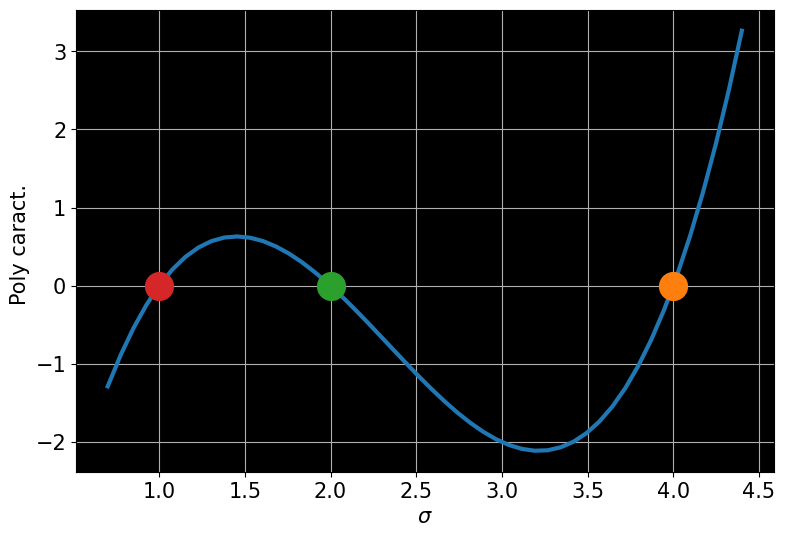

In [5]:
from sympy.solvers import solve
from sympy import symbols

print('\n Resolucao Simbolica - Sympy : ............................')
x = symbols('x')
def eqcar(x): return x**3 - I1*x**2 + I2*x - I3
print('\n Equacao carateristica:')
print(eqcar(x),' = 0')
valproprios = solve(eqcar(x), x, dict=True)
print('\n sol : ')
print(valproprios)
sI = valproprios[2][x]
sII = valproprios[1][x]
sIII = valproprios[0][x]
print('\n1º valor próprio, sI = ','{:.1f}'.format(sI))
print('2º valor próprio, sII = ','{:.1f}'.format(sII))
print('3º valor próprio, sIII = ','{:.1f}'.format(sIII))

print('\n Calculo invariantes Ii (sI,SII,sIII) : \n')
I1vp = sI + sII + sIII
print('I1 (sI,SII,sIII) = ','{:.1f}'.format(I1vp))
I2vp = sI*sII + sII*sIII + sI*sIII
print('I2 (sI,SII,sIII) = ','{:.1f}'.format(I2vp))
I3vp = sI*sII*sIII
print('I3 (sI,SII,sIII) = ','{:.1f}'.format(I3vp))

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valpropriosN)

print('\n Resolucao Analítica - Formula recursiva Poly3: ..........')
print('\n p(x) = x**3 + a x**2 + b*c + c = 0')
def frPoly3(a,b,c):
    p = b-a**2/3
    q = (2*a**3)/27 - (a*b)/3 + c
    DeltaPoly3 = q**2/4 + p**3/27
    print('\nDelta(Poly3) :', DeltaPoly3)
    if DeltaPoly3 < 0:
        print('existe três soluções reais')
        x1 = (2/np.sqrt(3))*np.sqrt(-p)*np.sin((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3))) - a/3
        x2 = -(2/np.sqrt(3))*np.sqrt(-p)*np.sin((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3)) + np.pi/3) - a/3
        x3 = (2/np.sqrt(3))*np.sqrt(-p)*np.cos((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3)) + np.pi/6) - a/3
    elif DeltaPoly3 == 0:
        print('existe três raízes repetidas')
        x1 = -2*(q/2)**(1/3) - a/3
        x2 = (q/2)**(1/3) - a/3
        x3 = x2
    else:
        print('existe apenas uma única solução real')
        x1 = (-q/2 + np.sqrt(DeltaPoly3))**(1/3) + (-q/2 - np.sqrt(DeltaPoly3))**(1/3) - a/3
        x2 = x1; x3 = x1

    return  np.array([x1,x2,x3])

valpropfrPoly3 = frPoly3(-I1,I2,-I3)
print('\n Formula recursiva Poly3 = ',valpropfrPoly3)

srange = np.linspace(valpropfrPoly3[1]*.7,valpropfrPoly3[2]*1.1)
def polycaract(s):
    return s**3 - I1*s**2 + I2*s - I3
import matplotlib.pyplot as plt
font = {'size'   : 15}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='black'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valpropriosN:
    plt.plot(i,polycaract(i),'o',markersize=20)
plt.ylabel('Poly caract. ')
plt.xlabel('$\sigma$')
plt.grid('on')
plt.show()

Uma vez conhecidas as tensões principais $\sigma_\alpha~(\alpha= \mathrm{I}, \mathrm{II}, \mathrm{III})$, os respetivos vetores próprios $\vec{n}_\alpha\equiv\vec{e}_\alpha~(\alpha= \mathrm{I}, \mathrm{II}, \mathrm{III})$ são determinados independentemente resolvendo o sistema de equações caratérístico:

\begin{equation*}
(\sigma_{ji} - \sigma\delta_{ij}) \cdot n_j  = 0
\quad\wedge\quad
n_{i} \cdot n_{i} = 1
\end{equation*}

De notar que a resolução simultânea do sitema de equações representado por $(\sigma_{ij} - \sigma\delta_{ij})\cdot n_i  = 0$, não conduz a uma solução única e bem determinada, porque as três equações não são independentes.

A primeira direção principal está associada ao valor próprio de tensão $\sigma_\mathrm{I} = 4$ MPa. Desenvolvendo o primeiro sistema de equações:

\begin{equation*}
\begin{cases}
(\sigma_{11}-\sigma_\mathrm{I})n_1 + \sigma_{12} n_2  + \sigma_{13} n_3 = 0 \\
\sigma_{21}n_1 + (\sigma_{22}-\sigma_\mathrm{I}) n_2  + \sigma_{23} n_3 = 0 \\
\sigma_{31}n_1 + \sigma_{32} n_2  + (\sigma_{33}-\sigma_\mathrm{I}) n_3 = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
(3-4)n_1 - n_2  + 0 = 0 \\
-n_1 + (3-4) n_2  + 0 = 0 \\
0 + 0  + (1-4) n_3 = 0
\end{cases}
\end{equation*}

ou na forma matricial:

\begin{equation*}
[A]\{x\} = \{b\} \Leftrightarrow
\begin{bmatrix}
-1 & -1 & 0 \\
-1 & -1 & 0 \\
0 & 0 & -3
\end{bmatrix}
\begin{bmatrix}
n_1 \\ n_2 \\ n_3
\end{bmatrix}=
\begin{bmatrix}
0\\0\\0
\end{bmatrix}
\end{equation*}

Facilmente pode verificar-se que a primeira e segunda equação são idênticas. De facto a matriz de coeficientes $[A]$ é singular, ou seja, $\det([A])=0$ pelo não admite inversa.

In [6]:
vp = float(valproprios[2][x])
lin1 = [(tt0[0,0] - vp), tt0[0,1], tt0[0,2]]
lin2 = [tt0[1,0], (tt0[1,1] - vp), tt0[1,2]]
lin3 = [tt0[2,0], tt0[2,1], (tt0[2,2] - vp)]
coefA = np.array([lin1,lin2,lin3])
print('coefA =\n',coefA)

detcoefA = np.linalg.det(coefA)
print('det(coefA) = ',detcoefA)

coefA =
 [[-1. -1.  0.]
 [-1. -1.  0.]
 [ 0.  0. -3.]]
det(coefA) =  0.0


Pelo que as direções (mas não os sentidos) do eixo principal associado a $\sigma_\mathrm{I}$ deve ser analiticamente obtido pelo seguinte sistema de equações lineares:

\begin{equation*}
\begin{cases}
-n_1 - n_2  + 0 = 0 \\
0 + 0  - n_3 = 0 \\
n_1n_1 + n_2n_2 + n_3n_3 = 1
\end{cases}
\end{equation*}

desenvolvendo algebricamente,

\begin{equation*}
\begin{cases}
n_1 = - n_2  \\
n_3 = 0 \\
n_1^2+ n_2^2 = 1
\end{cases} ~\Leftrightarrow~
\begin{cases}
n_1 = \pm 1/\sqrt{2} \\
n_2 = \pm 1/\sqrt{2} \\
n_3 = 0
\end{cases}
\end{equation*}

Determinadas as direções de $\vec{n}_\mathrm{I}$ associado à tensão principal $\sigma_{\mathrm{I}} = 4$ MPa considera-se os cossenos diretores com os seguintes sentidos:

\begin{equation*}
\vec{n}_{\mathrm{I}} = - \frac{1}{\sqrt{2}} \vec{e}_1 + \frac{1}{\sqrt{2}} \vec{e}_2
\end{equation*}

In [7]:
import sympy as sy
from sympy.matrices import Matrix

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (tt0[0,0] - vp)*d1 + tt0[0,1]*d2 + tt0[0,2]*d3
def eq2(d1,d2,d3,vp): return tt0[1,0]*d1 + (tt0[1,1] - vp)*d2 + tt0[1,2]*d3
def eq3(d1,d2,d3,vp): return tt0[2,0]*d1 + tt0[2,1]*d2 + (tt0[2,2] - vp)*d3
def eq4(d1,d2,d3): return d1**2 + d2**2 + d3**2 -1

def caleig(vp):
    print('\n(i) Sistema de equações:')
    E11 = eq1(d1,d2,d3,vp); print(E11,' = 0')
    E21 = eq2(d1,d2,d3,vp); print(E21,' = 0')
    E31 = eq3(d1,d2,d3,vp); print(E31,' = 0')
    E41 = eq4(d1,d2,d3); print(E41,' = 0')
    VetProp1 = solve([E11,E21,E31,E41], [d1,d2,d3], dict=True)
    lista0 = [VetProp1[0][d1],VetProp1[0][d2],VetProp1[0][d3]]
    lista1 = [VetProp1[1][d1],VetProp1[1][d2],VetProp1[1][d3]]
    return np.array([lista0,lista1])

# 1 valor proprio -------------------
vp1 = valproprios[2][x]
print('------------------------')
print(f'Valor próprio = {vp1:.2f} MPa')
print('------------------------')
mvers1 = caleig(vp1)

------------------------
Valor próprio = 4.00 MPa
------------------------

(i) Sistema de equações:
-1.0*d1 - d2  = 0
-d1 - 1.0*d2  = 0
-3.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0


De igual forma se pode determinar os restantes vetores próprios associados, respetivamente, aos valores próprios $\sigma_{\mathrm{II}}$ e $\sigma_{\mathrm{III}}$:

\begin{equation*}
\begin{aligned}
\vec{n}_{\mathrm{II}} &= \frac{1}{\sqrt{2}} \vec{e}_1 + \frac{1}{\sqrt{2}} \vec{e}_2 \\
\vec{n}_{\mathrm{III}} &= \vec{e}_3\\
\end{aligned}
\end{equation*}

In [8]:
# 2 valor proprio -------------------
vp2 = valproprios[1][x]
print('------------------------')
print(f'Valor próprio = {vp2:.2f} MPa')
print('------------------------')
mvers2 = caleig(vp2)

# 3 valor proprio -------------------
vp3 = valproprios[0][x]
print('------------------------')
print(f'Valor próprio = {vp2:.2f} MPa')
print('------------------------')
mvers3 = caleig(vp3)

print('\n------------------------')
print('Matriz Tranformacao')
print('------------------------')
T0P0 = np.vstack((mvers1[0,:],mvers2[0,:],mvers3[0,:]))
print('T0P0 - 1 caso - = \n',T0P0)
M = sy.Matrix(T0P0); detT0P0 = M.det()
print('det(T0P0) = ',detT0P0)

T0P1 = np.vstack((mvers1[1,:],mvers2[1,:],mvers3[1,:]))
print('\nT0P1 - 2 caso - = \n',T0P1)
M = sy.Matrix(T0P1); detT0P1 = M.det()
print('det(T0P1) = ',detT0P1)

if (abs(detT0P0 - 1.0) <= 1e-3):
    T0P = T0P0
elif (abs(detT0P1 - 1.0) <= 1e-3):
    T0P = T0P1

nI = T0P[0,:]
nII = T0P[1,:]
nIII = T0P[2,:]

print('\n------------------------')
print('RESUMO:')
print('------------------------')
print(f' Sigma I = {vp1:.3f} | nI = {nI}')
print(f' Sigma II = {vp2:.3f} | nII = {nII}')
print(f' Sigma III = {vp3:.3f} | nIII = {nIII}')

------------------------
Valor próprio = 2.00 MPa
------------------------

(i) Sistema de equações:
1.0*d1 - d2  = 0
-d1 + 1.0*d2  = 0
-1.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
------------------------
Valor próprio = 2.00 MPa
------------------------

(i) Sistema de equações:
2.0*d1 - d2  = 0
-d1 + 2.0*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

------------------------
Matriz Tranformacao
------------------------
T0P0 - 1 caso - = 
 [[-0.707106781186548 0.707106781186548 0.0]
 [-0.707106781186548 -0.707106781186548 0.0]
 [0.0 0.0 -1.00000000000000]]
det(T0P0) =  -1.00000000000000

T0P1 - 2 caso - = 
 [[0.707106781186548 -0.707106781186548 0.0]
 [0.707106781186548 0.707106781186548 0.0]
 [0.0 0.0 1.00000000000000]]
det(T0P1) =  1.00000000000000

------------------------
RESUMO:
------------------------
 Sigma I = 4.000 | nI = [0.707106781186548 -0.707106781186548 0.0]
 Sigma II = 2.000 | nII = [0.707106781186548 0.707106781186548 0.0]
 Sigma III = 1.000 | nIII = [0.0 0.0 1.00000

#### e) Verifique se a matriz: $[A]$ pode ser uma matriz de transformação de coordenadas.<a name="E"></a>
([enunciatum](#PI23))

Um tensor de segunda ordem pode assim ser simplificadamente definido:

*  > Um tensor de segunda ordem $\tilde{T}$ é um mapeamento linear
   >que permite transformar um vetor $\vec{v}$ num vetor $\vec{w}$, tal que:
   >$\vec{w} = \tilde{T} \vec{v}$

Estes tensores têm algumas propriedades como: ortogonalidade, simétria e anti-simétria, direções e valores próprios, equação característica. De entre estas, vamo-nos reter nesta alínea nos tensores ortogonais.

Um tensor de segunda ordem $\tilde{Q}$ é dito ortogonal se para qualquer par de vetores $\vec{a}$ e $\vec{b}$ se verificar:

\begin{equation*}
(\tilde{Q}\,\vec{a})\cdot(\tilde{Q}\,\vec{b}) = \vec{a}\cdot\vec{b}
\end{equation*}

Genericamente, isto quer dizer que o tensor $\tilde{Q}$ preserva, na transformação linear, a amplitude de, e os ângulos entre os vetores sobre os quais opera. Uma condição necessária e sufiente para verificar a equação anterior é:

\begin{equation*}
\tilde{Q}^\top \tilde{Q} = \tilde{Q} \tilde{Q}^\top = \tilde{I}
\end{equation*}

ou, de forma equivalente,

\begin{equation*}
\tilde{Q}^\top = \tilde{Q}^{-1}
\end{equation*}

Pode ser demostrado que $\det \tilde{Q} = \pm 1$. Assim sendo, um tensor ortogonal $\tilde{Q}$ é dito uma transformação própria se $\det \tilde{Q} = 1$. Caso contrário, se $\det \tilde{Q} = -1$, o tensor ortogonal é impróprio.

À luz do mapeamento linear entre vetores, uma transformação ortogonal própria corresponde a uma rotação; enquanto que uma transformação ortogonal imprópria envolve uma rotação e uma reflexão.

Considere-se agora a aplicação da transformação entre tensores de segunda ordem. Por definição, esta transformação ocorre de acordo com a seguinte relação:

\begin{equation*}
\sigma_{kl} = a_{ki}a_{lj}\sigma_{ij}
\end{equation*}

onde $\sigma_{ij}$ são as componentes do tensor das tensões num ponto em relação ao referencial $P(x_1,x_2,x_3)$, $\sigma_{kl}$ tensor das tensões em relação a outro referencial $P(x_1',x_2',x_3')$ e $a_{ki}$ é a matriz de transformação de coordenadas.

Se a matriz de tranformação $[A]$ enunciada verificar a seguinte condição: $[A][A]^T=[I]$, será um tensor ortogonal, passível de representar um mapemanento linear entre vetores ou tensores.

In [9]:
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})

def mata(v1,v2,v3):
    return np.array([v1,v2,v3])

A = mata(versor(-1/np.sqrt(2),1/np.sqrt(2),0),
         versor(1/np.sqrt(2),1/np.sqrt(2),0),
         versor(0,0,1))
print('\n [A] = \n',A)
Ident = np.dot(A,np.transpose(A))
print('\n [A][A]^T = \n',Ident)
print('\n det([A]) = ','{:.2f}'.format(np.linalg.det(A)))



 [A] = 
 [[-0.707  0.707  0.000]
 [ 0.707  0.707  0.000]
 [ 0.000  0.000  1.000]]

 [A][A]^T = 
 [[ 1.000  0.000  0.000]
 [ 0.000  1.000  0.000]
 [ 0.000  0.000  1.000]]

 det([A]) =  -1.00


Conclui-se que:

- a matriz $[A]$ verifica a condição: $[A][A]^T = [I]$.
- a transformação é dita imprópria uma vez que $\det([A]) = -1$.

**Verificação**

Será a matriz de transformação definda em $[A]$ uma transformação de um sistema de coordenadas de referência para o referencial principal?

Faça-se um cálculo complementar. Considere-se os valores próprios, arranjados numa matriz diagonal, $\underline{\underline{\Gamma}}$. Esta matriz representa o tensor das tensões no referencial principal.

Considere-se agora a transformação do referencial principal para o referencial arbitrário de referêncial

\begin{equation*}
[\sigma] = [A]^{-1}[\Gamma][A]
\end{equation*}

de notar que as colunas da matriz $[A]$ são os vetores próprios da matriz $[\sigma]$.

In [10]:
np.set_printoptions(precision=2,suppress=True)

def sigmavP(i1,i2,i3): return np.array([[i1,0,0],[0,i2,0],[0,0,i3]])

sig2 = np.dot(np.dot(np.linalg.inv(A),sigmavP(sI,sII,sIII)),A)
print(f'sigma [MPa]: \n {sig2}')


sigma [MPa]: 
 [[3.00000000000000 -1.00000000000000 0]
 [-1.00000000000000 3.00000000000000 0]
 [0 0 1.00000000000000]]


### Apêndice A.
Um polinómio de grau 3 pode ser genericamente escrito por:

\begin{equation*}
P(x) = a_3 x^3 + a_2 x^2 +  a_1 x  +  a_0
\end{equation*}

O teorema fundamental da álgebra garante que se $a_0$, $a_1$, $a_2$ e $a_3$ forem números reais,
então pode-se fatorizar o polinômio cúbico na forma:

\begin{equation*}
P(x) = a_3(x-b_1)(x^2 +  b_2 x  +  b_3)
\end{equation*}

A fatorização do polinómio de 3 grau permite reescrever a equação caraterística como a multiplicação de
polinómios de 1 e 2 graus.


Em álgebra, o teorema das raízes racionais (ou teorema dos zeros racionais, ou teorema $p/q$) diz que as possíveis
raízes de um polinômio são os fatores do último termo dividido pelos fatores do primeiro termo:

\begin{equation*}
\pm \frac{\textrm{fatores de $a_0$}}{\textrm{fatores de $a_3$}}
\end{equation*}

Para o polinómio da equaão caraterística:

\begin{equation*}
p(\lambda) = \lambda^3 - 7\lambda^2 + 14\lambda - 8 = 0
\end{equation*}


têm-se, neste caso:

\begin{equation*}
\pm \frac{\textrm{fatores de 8}}{\textrm{fatores de 1}} = \pm  \frac{1,2,4,8}{1} = \pm 1,2,4,8
\end{equation*}

Pelo que as possíveis raízes da equação caraterística são: $\pm 1,2,4,8$.
Note-se, além disso, que para o primeiro termo $+1$ têm-se: $p(1) = 0$.
Ou seja, 1 é um zero do polinómio. Isto significa que $(\lambda -1)$ é um fator do polinómio da
equação caraterística. Este resultado já tinha sido obtido diretamente pela observação dos
componentes do tensor das tenões na direção $x_3$, que é uma direção principal de tensão:
$\vec{t}^{(\vec{k})}  = \sigma_{zz} \vec{k}$.

O passo seguinte consiste em realizar a seguinte divisão de polinómios:

\begin{equation*}
\frac{\lambda^3 - 7\lambda^2 + 14\lambda - 8}{\lambda - 1}
\end{equation*}

O seguinte algoritmo pode ser usado:

i) dividir primeiros termos em ambos os membros: $\lambda^3 / \lambda$, cujo resultado é
$\therefore \lambda^2$

ii) multiplicar $\lambda^2$ pelo denominador $(\lambda - 1)$  $\therefore \lambda^3 - \lambda^2$

iii) subtrair parte do nomerador (com termos comuns): $\lambda^3 - 7\lambda^2$ ao resultado anterior (ii)
$\lambda^3 - \lambda^2$ $\therefore-6\lambda^2$

iv) juntar restantes parcelas do numerador ao resultado anterior (iii): $\therefore -6\lambda^2 + 14\lambda - 8$

\begin{equation*}
\frac{-6\lambda^2 + 14\lambda - 8}{\lambda - 1}
\end{equation*}

v) repetir divisão de parcelas de ordem superior, neste caso: $-6\lambda^2/ \lambda$ $\therefore -6\lambda$

vi) multiplicar $-6\lambda$ pelo denominador $(\lambda - 1)$  $\therefore -6\lambda^2 + 6\lambda$

vii) subtrair parte do nomerador (com termos comuns): $-6\lambda^2 + 14\lambda$ ao resultado anterior
$-6\lambda^2 + 6\lambda$ $\therefore8\lambda$

viii) juntar restantes parcelas do numerador ao resultado anterior: $\therefore 8\lambda - 8$

\begin{equation*}
\frac{8\lambda - 8}{\lambda - 1}
\end{equation*}

ix) $8\lambda / \lambda = 8$ > $8(\lambda -1)$ > 0\

Pelo que

\begin{equation*}
p(\lambda) = (\lambda-1)(\lambda^2 - 6\lambda + 8) = 0
\end{equation*}

Por curiosidade, refere-se que não existem soluções analíticas para raízes de polinómios de ordem igual ou
superior a 5. Este é o teorema de Abel-Ruffini provado no Século XIX.


### Apêndice B. Fórmula cúbica

Considere uma equação cúbica na forma

\begin{equation*}
x^3 + a x^2 + bx + c  = 0
\end{equation*}

Note-se que,é sempre possível dividir a equação pelo coeficiente de $x^3$ para que este seja sempre igual a 1.


A solução (determinação das raízes) do polinómio de grau 3 pode ser obtida pelos seguinte algoritmo:

Passo 1:

Determinar,

\begin{equation*}
p = b-\frac{a^2}{3} \quad \mathrm{e} \quad q = \frac{2a^3}{27} - \frac{ab}{3} + c
\end{equation*}

e

\begin{equation*}
\Delta = \frac{q^2}{4}  + \frac{p^3}{27}
\end{equation*}

Passo 2:

Caso I: $\Delta > 0$. Neste caso existe apenas uma única solução real. As raízes são:

\begin{equation*}
x = \left( -\frac{q}{2} + \sqrt{\Delta} \right)^{1/3} + \left( -\frac{q}{2} - \sqrt{\Delta} \right)^{1/3}
- \frac{a}{3}
\end{equation*}


Caso II: $\Delta = 0$. Neste caso existe três raízes repetidas. As raízes são:

\begin{equation*}
\begin{aligned}
x_1 &= -2\left(\frac{q}{2}\right)^{1/3} - \frac{a}{3}  \\
x_2 &= x_3 = \left(\frac{q}{2}\right)^{1/3} - \frac{a}{3}
\end{aligned}
\end{equation*}

Caso III: $\Delta < 0$. Neste caso existe três soluções reais.

\begin{equation*}
\begin{aligned}
x_1 &= \frac{2}{\sqrt{3}}\sqrt{-p}\sin\left[ \frac{1}{3} \arcsin \left(  \frac{3\sqrt{3}q}{2(\sqrt{-p})^3}
\right) \right] - \frac{a}{3} \\
x_2 &= -\frac{2}{\sqrt{3}}\sqrt{-p}\sin\left[ \frac{1}{3} \arcsin \left(  \frac{3\sqrt{3}q}{2(\sqrt{-p})^3}
\right) + \frac{\pi}{3} \right] - \frac{a}{3} \\
x_3 &= \frac{2}{\sqrt{3}}\sqrt{-p}\cos\left[ \frac{1}{3} \arcsin \left(  \frac{3\sqrt{3}q}{2(\sqrt{-p})^3}
\right) + \frac{\pi}{6} \right] - \frac{a}{3}
\end{aligned}
\end{equation*}

### Apêndice C. Sistema de coordenadas direto

A faceta para a qual a direção do vetor tensão coincide com a normal que a define, conduz,à seguinte condição:

\begin{equation*}
(\sigma_{ij} - \sigma \delta_{ij} ) \cdot n_i = 0   \quad\wedge\quad
n_j \cdot n_j = 1
\end{equation*}

A solução deste sistema de equações, considerando as tensões principais, $\sigma_\alpha~(\alpha = \mathrm{I},\mathrm{II},\mathrm{III})$, previamente calculadas pela equação: $\det(\sigma_{ij} - \sigma \delta_{ij})=0$, conduz à determinação das direções principais, $n_\alpha~(\alpha = \mathrm{I},\mathrm{II},\mathrm{III})$. Contudo, esta solução não determina diretamente os sentidos para estes versores, mas apenas as suas direções no espaço, em relação a um sistema de coordenadas ortonormado e direto inicial.

Por outras palavras, se $n_\alpha~(\alpha = \mathrm{I},\mathrm{II},\mathrm{III})$ define uma direção principal também o será
o versor $-n_\alpha~(\alpha = \mathrm{I},\mathrm{II},\mathrm{III})$.

Resta-nos portanto definir um sistema de coordenadas principal que satisfaça a regra da mão direita, ou seja, o seguinte produto misto:

\begin{equation*}
\vec{e}_1 \cdot ( \vec{e}_2 \times \vec{e}_3)  = \det([Q]) = +1
\end{equation*}

Conclui-se ainda, apesar de nem sempre ser esta a via escolhida para a resolução dos problemas propostos (diria por uma questão de simplicidade e visualização conceptual), que será sempre possível escolher um sistema de coordenadas ortonormado e direto para o qual a matriz do tensor das tensões, nesse referencial principal, possa ser escrito por:

\begin{equation*}
\sigma_p =
\begin{bmatrix}
\sigma_\mathrm{I} & 0 & 0 \\
0 & \sigma_\mathrm{II} & 0 \\
0 & 0 & \sigma_\mathrm{III}
\end{bmatrix}
\end{equation*}

com $\sigma_\mathrm{I} > \sigma_\mathrm{II} > \sigma_\mathrm{III}$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/SCdireto.jpg" width="500" height="350">

### Apêndice D. eig()

---------------------
vvp - 1 :
---------------------
valor proprio :  4.0
vetor proprio :  [ 0.71 -0.71  0.  ]
---------------------
vvp - 2 :
---------------------
valor proprio :  2.0
vetor proprio :  [0.71 0.71 0.  ]
---------------------
vvp - 3 :
---------------------
valor proprio :  1.0
vetor proprio :  [0. 0. 1.]
---------------------
sistema coord. ortonormado e direto :
---------------------
base/eixos principal = 
 [[ 0.71 -0.71  0.  ]
 [ 0.71  0.71  0.  ]
 [ 0.    0.    1.  ]]


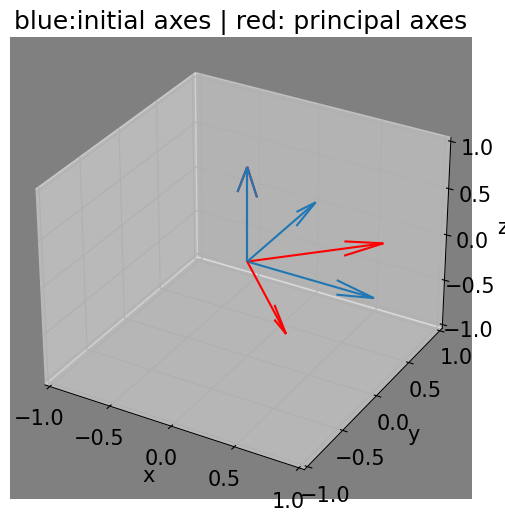

In [11]:
#eigenvectors and eigenvalues
eig_val, eig_vec = np.linalg.eig(tt0)

print('---------------------')
print('vvp - 1 :')
print('---------------------')
print('valor proprio : ',eig_val[0])
print('vetor proprio : ',eig_vec[:,0])
print('---------------------')
print('vvp - 2 :')
print('---------------------')
print('valor proprio : ',eig_val[1])
print('vetor proprio : ',eig_vec[:,1])
print('---------------------')
print('vvp - 3 :')
print('---------------------')
print('valor proprio : ',eig_val[2])
print('vetor proprio : ',eig_vec[:,2])
print('---------------------')
print('sistema coord. ortonormado e direto :')
print('---------------------')
basep = np.transpose(eig_vec)
print('base/eixos principal = \n',basep)

# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

plte1 = [0,0,0,basep[0,0],basep[0,1],basep[0,2]]
plte2 = [0,0,0,basep[1,0],basep[1,1],basep[1,2]]
plte3 = [0,0,0,basep[2,0],basep[2,1],basep[2,2]]
setas = np.array([plte1, plte2, plte3])
fig = plt.figure(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
ax = fig.add_subplot(111, projection='3d')
for i in setas:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength,
              color='r')
plte1ini = [0,0,0,1,0,0]
plte2ini = [0,0,0,0,1,0]
plte3ini = [0,0,0,0,0,1]
baseini = np.array([plte1ini, plte2ini, plte3ini])
for i in baseini:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
plt.title('blue:initial axes | red: principal axes')
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### EigenCalc

<a href="http://www.geo.cornell.edu/geology/faculty/RWA/programs/utility-programs/eigencalc.html" target="_blank"> <span
style="color:#333399"> EigenCalc

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/Au02_P003_EigenCalc.jpg"
width="400" height="400">






---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

